# Imports and Load Data

In [18]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import ast
import json
from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from datetime import datetime

In [8]:
# Load the dataset
df = pd.read_csv("Data\\classified_comment_stance_with_features.csv", encoding='utf-8')

# Display basic info
print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())

# Show a small sample
display(df.sample(5))

Shape: (605822, 30)

Column Names: ['comment_id', 'self_text', 'created_time', 'author_name', 'ups', 'downs', 'score', 'post_id', 'subreddit', 'post_self_text', 'post_title', 'post_created_time', 'post_score', 'user_mentions', 'media_links', 'predicted_label', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'sentiment_score', 'factual_score', 'belief_score', 'emotionality_score', 'super_topics', 'super_similarities', 'selected_topics', 'num_selected_topics']


,comment_id,self_text,created_time,author_name,ups,downs,score,post_id,subreddit,post_self_text,...,insult,identity_hate,sentiment_score,factual_score,belief_score,emotionality_score,super_topics,super_similarities,selected_topics,num_selected_topics
54937,mlsvj61,1. I said prior to the formation of Israel. Be...,2025-04-07 02:32:49,Laicey,7,0,7,1jt2a6p,IsraelPalestine,Sorry if I sounds like an ignorant and stupid ...,...,0.056127,0.399497,-0.833549,0.350935,0.454429,0.950441,"['Arab-Israel Conflict', 'Settlements/Ethnic C...","[0.5639102, 0.49393207, 0.45968282, 0.3978242,...",['Arab-Israel Conflict'],1
203976,lhny1ao,I buy this argument. I do. I get it. Ill accep...,2024-08-11 23:24:31,ThirstyTarantulas,1,0,1,1epxb4x,IsraelPalestine,"Growing up, I always thought that land belongs...",...,0.031748,0.176328,-0.666420,0.365868,0.369357,0.781473,"['Arab-Israel Conflict', 'Zionism', 'Palestini...","[0.50789934, 0.44220614, 0.398218, 0.39789343,...",['Arab-Israel Conflict'],1
138461,ltvzc2r,You seem to be ignoring the fact that Israel a...,2024-10-26 18:27:04,Paradigm21,1,0,1,1gbp2my,IsraelPalestine,"For those of us not from this region, its diff...",...,0.114471,0.138239,-0.601347,0.294889,0.425095,0.165036,"['Arab-Israel Conflict', 'Zionism', 'Terrorism...","[0.60993505, 0.44321212, 0.4177548, 0.41772208...",['Arab-Israel Conflict'],1
206294,lh6u53z,"None of this serves to justify any invasion, i...",2024-08-08 23:07:38,emckillen,1,0,1,1ena78r,IsraelPalestine,"Under The Geneva convention, occupied people h...",...,0.049221,0.055838,-0.793477,0.419350,0.307165,0.623512,"['Arab-Israel Conflict', 'Zionism', 'Palestini...","[0.6122969, 0.4672685, 0.43672824, 0.401908, 0...",['Arab-Israel Conflict'],1
431882,ki7f1s1,"I'm confused by your boyfriend's position, but...",2024-01-17 00:09:46,charliekiller124,4,0,4,198hn6y,IsraelPalestine,I saw a Twitter by someone who said that the p...,...,0.062859,0.064505,-0.920065,0.310318,0.421182,0.826356,"['Arab-Israel Conflict', 'Terrorism/HAMAS', 'I...","[0.59384483, 0.5550159, 0.47981885, 0.4644187,...","['Arab-Israel Conflict', 'Terrorism/HAMAS']",2


# Stats

In [9]:
# --- Config ---
affil_col = "predicted_label"
group_a, group_b = "Pro-Israel", "Pro-Palestine"

columns_to_keep = [
    "comment_id","created_time","author_name", "score","predicted_label","toxic","severe_toxic",
    "obscene","threat","insult","identity_hate","sentiment_score","factual_score",
    "belief_score","emotionality_score","selected_topics"
]

features = [
    "score","toxic","severe_toxic","obscene","threat","insult","identity_hate",
    "sentiment_score","factual_score","belief_score","emotionality_score"
]

df = df[columns_to_keep].dropna(subset=[affil_col])


In [10]:
# --- Helpers ---
def parse_topics(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    s = str(x).strip()
    # Try JSON
    try:
        val = json.loads(s)
        return val if isinstance(val, list) else []
    except Exception:
        pass
    # Try Python-literal list
    try:
        val = ast.literal_eval(s)
        return val if isinstance(val, list) else []
    except Exception:
        return []

def sig_mark(p):
    return "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))


In [11]:
# Standardize affiliation values (optional; comment out if not needed)
df[affil_col] = df[affil_col].astype(str).str.strip()

# Parse topics
df["selected_topics"] = df["selected_topics"].apply(parse_topics)

# Build exploded view for subtopic-level tests
exp = df.explode("selected_topics").rename(columns={"selected_topics":"subtopic"})
exp["subtopic"] = exp["subtopic"].fillna("")

# Include a TOTAL pseudo-topic
exp_total = exp.copy()
exp_total["subtopic"] = "TOTAL"
exp_all = pd.concat([exp, exp_total], ignore_index=True)

# Keep only the two groups
exp_all = exp_all[exp_all[affil_col].isin([group_a, group_b])].copy()

# --- T-tests ---
rows = []
for topic in sorted(exp_all["subtopic"].dropna().unique(), key=lambda x: (x!="TOTAL", x)):
    topic_df = exp_all[exp_all["subtopic"] == topic]

    for feat in features:
        if feat not in topic_df.columns:
            continue

        a = pd.to_numeric(topic_df.loc[topic_df[affil_col]==group_a, feat], errors="coerce").dropna()
        b = pd.to_numeric(topic_df.loc[topic_df[affil_col]==group_b, feat], errors="coerce").dropna()

        # Need at least 2 per group for a stable Welch t-test
        if len(a) < 2 or len(b) < 2:
            pval = np.nan
            tval = np.nan
        else:
            tval, pval = ttest_ind(a, b, equal_var=False, nan_policy="omit")

        rows.append({
            "subtopic": topic,
            "feature": feat,
            f"n_{group_a}": len(a),
            f"n_{group_b}": len(b),
            f"mean_{group_a}": np.nan if len(a)==0 else a.mean(),
            f"mean_{group_b}": np.nan if len(b)==0 else b.mean(),
            "diff_(A-B)": (a.mean() - b.mean()) if (len(a)>0 and len(b)>0) else np.nan,
            "t": tval,
            "p": pval,
            "sig": sig_mark(pval) if pd.notna(pval) else ""
        })

res = pd.DataFrame(rows)

# Sort: significant first (by p), then by topic, then feature
res_sorted = res.sort_values(by=["p","subtopic","feature"], na_position="last").reset_index(drop=True)

# Pretty display: round numeric columns for readability
display_cols = [
    "subtopic","feature",
    f"n_{group_a}", f"n_{group_b}",
    f"mean_{group_a}", f"mean_{group_b}",
    "diff_(A-B)","t","p","sig"
]
pretty = res_sorted[display_cols].copy()
pretty[[f"mean_{group_a}", f"mean_{group_b}", "diff_(A-B)", "t", "p"]] = \
    pretty[[f"mean_{group_a}", f"mean_{group_b}", "diff_(A-B)", "t", "p"]].round(4)

# Notebook-friendly print
with pd.option_context("display.max_rows", 200, "display.max_columns", None, "display.width", 140):
    print(f"Welch t-tests ({group_a} vs {group_b}) by subtopic (including TOTAL).")
    print("* p<.05, ** p<.01, *** p<.001")
    display(pretty)

Welch t-tests (Pro-Israel vs Pro-Palestine) by subtopic (including TOTAL).
* p<.05, ** p<.01, *** p<.001


,subtopic,feature,n_Pro-Israel,n_Pro-Palestine,mean_Pro-Israel,mean_Pro-Palestine,diff_(A-B),t,p,sig
0,Antisemitism,identity_hate,29427,30473,0.2336,0.1716,0.0620,56.8608,0.0000,***
1,Antisemitism,toxic,29427,30473,0.6522,0.7184,-0.0661,-57.5547,0.0000,***
2,Arab-Israel Conflict,emotionality_score,260400,228709,0.6876,0.7420,-0.0544,-65.9398,0.0000,***
3,Arab-Israel Conflict,insult,260400,228709,0.0549,0.0488,0.0061,66.1966,0.0000,***
4,Arab-Israel Conflict,obscene,260400,228709,0.0620,0.0538,0.0082,45.8794,0.0000,***
...,...,...,...,...,...,...,...,...,...,...
215,Pluralism/Liberal Values,score,3517,2797,24.8249,24.2327,0.5921,0.2038,0.8385,
216,Protests,severe_toxic,546,451,0.0260,0.0257,0.0003,0.1818,0.8558,
217,Protests,threat,546,451,0.0340,0.0342,-0.0002,-0.1190,0.9053,
218,Two-State Solution,obscene,214,112,0.0691,0.0684,0.0007,0.0946,0.9248,


In [12]:
pretty[pretty['feature']=='belief_score']

,subtopic,feature,n_Pro-Israel,n_Pro-Palestine,mean_Pro-Israel,mean_Pro-Palestine,diff_(A-B),t,p,sig
58,Palestinian Identity,belief_score,8314,9159,0.3050,0.3697,-0.0647,-18.9033,0.0000,***
106,Civilian Casualties,belief_score,11799,17016,0.3382,0.3199,0.0183,8.0521,0.0000,***
131,Genocide/War Crimes,belief_score,8436,20994,0.3230,0.3094,0.0136,4.9736,0.0000,***
140,Ceasefire Talks,belief_score,21937,3577,0.3308,0.3435,-0.0127,-3.7367,0.0002,***
142,Pluralism/Liberal Values,belief_score,3517,2797,0.3347,0.3116,0.0230,3.6779,0.0002,***
150,TOTAL,belief_score,608777,581153,0.3375,0.3363,0.0012,3.2069,0.0013,**
151,Nazi Comparison,belief_score,570,5186,0.3227,0.2927,0.0300,3.0093,0.0027,**
158,Zionism,belief_score,52617,94506,0.3326,0.3356,-0.0030,-2.6900,0.0071,**
161,Antisemitism,belief_score,29427,30473,0.3461,0.3420,0.0041,2.5225,0.0117,*
162,Arab-Israel Conflict,belief_score,260400,228709,0.3415,0.3428,-0.0013,-2.4259,0.0153,*


# Additional Discourse Analysis

## Engagement Analysis

In [ ]:
# Ensure datetime
df["created_time"] = pd.to_datetime(df["created_time"])

# Filter to the two stance groups
df_pol = df[df["predicted_label"].isin(["Pro-Israel", "Pro-Palestine"])].copy()

# Create month period
df_pol["month"] = df_pol["created_time"].dt.to_period("M").dt.to_timestamp()

# --- Monthly counts ---
monthly_counts = (
    df_pol
    .groupby(["month", "predicted_label"])
    .size()
    .reset_index(name="comment_count")
)

# --- Monthly active users ---
monthly_users = (
    df_pol
    .groupby(["month", "predicted_label", "author_name"])
    .size()
    .reset_index(name="n_comments")
)

avg_comments_per_user = (
    monthly_users
    .groupby(["month", "predicted_label"])["n_comments"]
    .mean()
    .reset_index(name="avg_comments_per_user")
)

# Merge
monthly = pd.merge(
    monthly_counts,
    avg_comments_per_user,
    on=["month", "predicted_label"],
    how="inner"
)

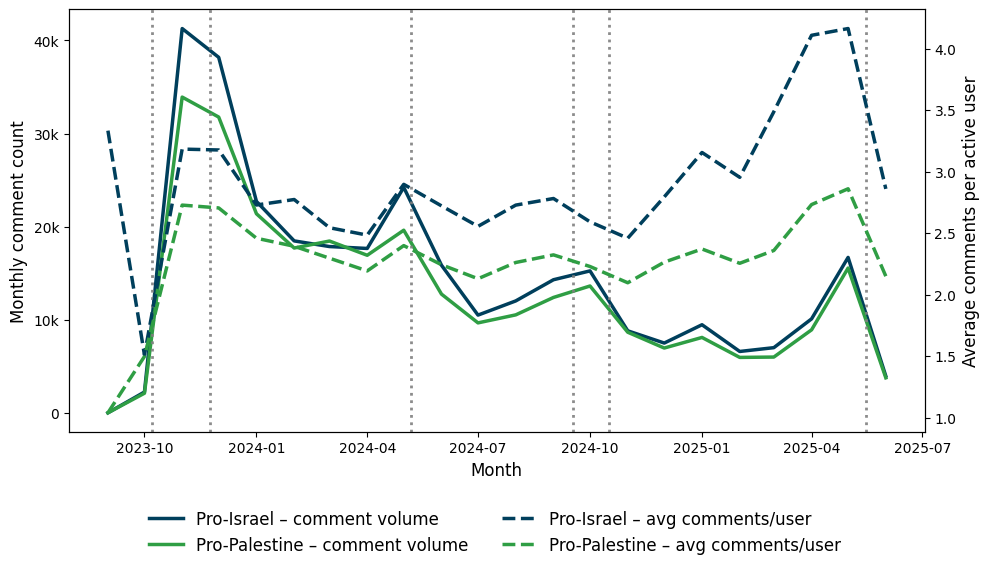

In [30]:
# Font sizes tuned for single-column figures
AXIS_LABEL_SIZE = 12
TICK_LABEL_SIZE = 10
LEGEND_SIZE = 12

colors = {
    "Pro-Israel": "#003f5c",
    "Pro-Palestine": "#2f9e44"
}

events = [
    ("Oct 7th\nAttack", datetime(2023, 10, 7)),
    ("First\nCeasefire", datetime(2023, 11, 24)),
    ("Rafah\nOperation", datetime(2024, 5, 7)),
    ("Beeper\nOperation", datetime(2024, 9, 17)),
    ("Sinwar\nAssassination", datetime(2024, 10, 17)),
    ("Merkavot\nGideon", datetime(2025, 5, 16)),
]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

for stance in ["Pro-Israel", "Pro-Palestine"]:
    data = monthly[monthly["predicted_label"] == stance]
    
    # Comment volume (solid line)
    ax1.plot(
        data["month"],
        data["comment_count"],
        label=f"{stance} – comment volume",
        color=colors[stance],
        linewidth=2.5
    )
    
    # Avg comments per user (dashed line)
    ax2.plot(
        data["month"],
        data["avg_comments_per_user"],
        label=f"{stance} – avg comments/user",
        color=colors[stance],
        linestyle="--",
        linewidth=2.5
    )

# Event lines
for _, date in events:
    ax1.axvline(
        date,
        color="gray",
        linestyle=":",
        linewidth=2,
        alpha=0.9
    )

ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x/1000)}k" if x >= 1000 else f"{int(x)}")
)

ax1.set_ylabel("Monthly comment count", fontsize=AXIS_LABEL_SIZE)
ax2.set_ylabel("Average comments per active user", fontsize=AXIS_LABEL_SIZE)
ax1.set_xlabel("Month", fontsize=AXIS_LABEL_SIZE)
ax1.tick_params(axis="both", labelsize=TICK_LABEL_SIZE)
ax2.tick_params(axis="y", labelsize=TICK_LABEL_SIZE)

# Legend (combined)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.15),
    fontsize=LEGEND_SIZE
)

plt.tight_layout()
plt.show()